In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
data = pd.read_csv('train.csv')
data = data[data['label'] == 1]
data = data.drop('label', axis=1)
data = data.dropna()

In [3]:
data = data.groupby('user_id')['text'].apply(lambda x: ' '.join(x)).reset_index()
user_profile = data.copy()
user_profile.head()

,user_id,text
0,U100,sport baseball_mlb solomon astro team octob ne...
1,U1000,lifestyl lifestylevideo kaia gerber is latest ...
2,U10001,sport baseball_mlb mlb umpir eric cooper dead ...
3,U10003,news newsworld exclus turkey bomb us special f...
4,U10008,news newsfactcheck fact check trump fals claim...


In [4]:
test = pd.read_csv('test.csv')
test = test.dropna()

In [5]:
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
corpus = user_profile['text'].tolist() + test['text'].tolist()
vectorizer = TfidfVectorizer()
X = vectorizer.fit_transform(corpus)

user_profile_vector = X[:len(user_profile)]
test_vector = X[len(user_profile):]




In [6]:

user_id_to_index = {uid: idx for idx, uid in enumerate(user_profile['user_id'])}




In [7]:
similarities = []
test = test.reset_index(drop=True)


for i, row in test.iterrows():
    user_id = row['user_id']
    user_idx = user_id_to_index.get(user_id)

    if user_idx is not None:
        sim = cosine_similarity(test_vector[i], user_profile_vector[user_idx])[0][0]
    else:
        sim = 0 

    similarities.append(sim)



In [15]:
from sklearn.metrics import roc_auc_score, accuracy_score

test['similarity'] = similarities
auc = roc_auc_score(test['label'], test['similarity'])
acc = accuracy_score(test['label'], (test['similarity'] > 0.2).astype(int))

print(f"📊 AUC Score: {auc:.4f}")
print(f"✅ Accuracy (threshold=0.5): {acc:.4f}")

📊 AUC Score: 0.5117
✅ Accuracy (threshold=0.5): 0.6484


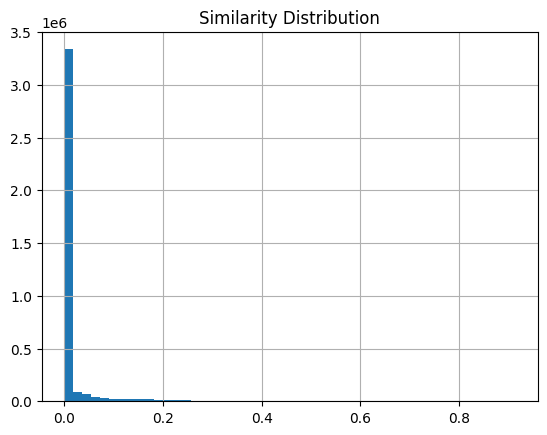

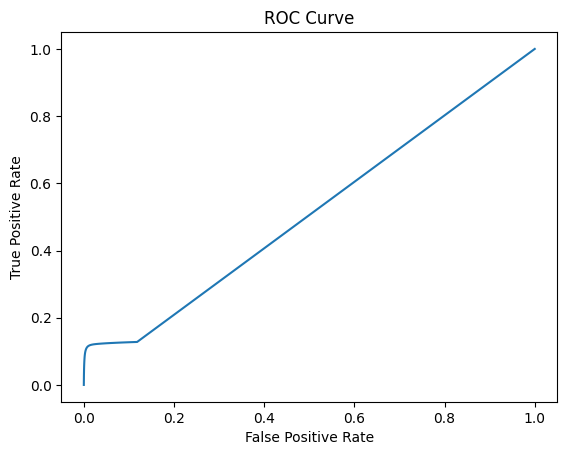

In [9]:
test1 = test.copy()
test['similarity'].hist(bins=50)
plt.title('Similarity Distribution')
plt.show()

## plot the ROC curve
from sklearn.metrics import roc_curve
fpr, tpr, thresholds = roc_curve(test['label'], test['similarity'])
plt.plot(fpr, tpr)
plt.title('ROC Curve')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.show()


In [10]:
# DataFrame with columns: user_id, predicted_score, label (1 if clicked, 0 otherwise)
df = test.copy()


import numpy as np
from sklearn.metrics import roc_auc_score

# --- Metric Functions ---
def dcg_score(y_true, y_score, k=10):
    order = np.argsort(y_score)[::-1]
    y_true = np.take(y_true, order[:k])
    gains = 2 ** y_true - 1
    discounts = np.log2(np.arange(len(y_true)) + 2)
    return np.sum(gains / discounts)

def ndcg_score_custom(y_true, y_score, k=10):
    best = dcg_score(y_true, y_true, k)
    actual = dcg_score(y_true, y_score, k)
    return actual / best if best > 0 else 0

def mrr_score(y_true, y_score):
    order = np.argsort(y_score)[::-1]
    y_true = np.take(y_true, order)
    rr_score = y_true / (np.arange(len(y_true)) + 1)
    return np.sum(rr_score) / np.sum(y_true) if np.sum(y_true) > 0 else 0

def reciprocal_rank(y_true, y_score):
    order = np.argsort(y_score)[::-1]
    y_true = np.take(y_true, order)
    # top 5
    for i in range(5):
        if y_true[i] == 1:
            return 1/(i+1)
    return 0




In [12]:
# df: must have user_id, label (0/1), score (probability)
def compute_metrics(df):
    aucs, mrrs,rrs, ndcg5s, ndcg10s = [], [], [], [], []

    for user_id, group in df.groupby('user_id'):
        y_true = group['label'].values
        y_score = group['similarity'].values

        if len(np.unique(y_true)) < 2:
            # AUC needs both classes
            continue

        auc = roc_auc_score(y_true, y_score)
        mrr = mrr_score(y_true, y_score)
        rr = reciprocal_rank(y_true, y_score)
        ndcg5 = ndcg_score_custom(y_true, y_score, k=5)
        ndcg10 = ndcg_score_custom(y_true, y_score, k=10)

        aucs.append(auc)
        mrrs.append(mrr)
        rrs.append(rr)
        ndcg5s.append(ndcg5)
        ndcg10s.append(ndcg10)

    print(len(aucs), len(mrrs), len(rrs), len(ndcg5s), len(ndcg10s))

    # Average across all users
    return {
        'AUC': np.mean(aucs),
        'MRR': np.mean(mrrs),
        'RR': np.mean(rrs),
        'nDCG@5': np.mean(ndcg5s),
        'nDCG@10': np.mean(ndcg10s)
    }


metrics = compute_metrics(df)
print(metrics)


50000 50000 50000 50000 50000
{'AUC': 0.5509726151617089, 'MRR': 0.12298928664955211, 'RR': 0.617931, 'nDCG@5': 0.4866668414417157, 'nDCG@10': 0.5062567765023334}
